## 🤖 Auswahl des Machine-Learning-Algorithmus

Zur Lösung der Problemstellung wurde ein **überwachtes Klassifikationsmodell** eingesetzt,  
da das Ziel darin besteht, anhand **vor dem Rennen bekannter Merkmale** vorherzusagen,  
ob ein Fahrer eine **Top-10-Platzierung** erreicht oder nicht.

---

### 🧠 Primärer Algorithmus: **Logistische Regression**

#### 📝 Begründung der Modellwahl:
- ✅ Etabliertes **Baseline-Modell** für binäre Klassifikationsprobleme  
- 📊 Besonders geeignet für **strukturierte tabellarische Daten**  
- 🔍 **Gut interpretierbar** – Einfluss einzelner Merkmale über Modellkoeffizienten nachvollziehbar  
- ⚙️ **Geringe Rechenkomplexität** → stabile & reproduzierbare Ergebnisse

---

### 🌳 Ergänzend: **Random-Forest-Klassifikator**

Ein **Random Forest** wurde zusätzlich trainiert, um einen **leistungsstärkeren, nicht-linearen Ansatz** zum Vergleich heranzuziehen.  
Dadurch konnte überprüft werden, ob **komplexere Zusammenhänge** die **Vorhersageleistung verbessern**.


In [99]:
import pandas as pd
import numpy as np


In [100]:
feature_df = pd.read_csv("../data/processed/driver_race_features.csv")
print(feature_df.shape)
feature_df.head()


(25121, 17)


,season,round,raceId,race_date,driverId,driver_name,constructorId,constructor_name,circuitId,circuit_name,grid,driver_experience,driver_recent_form,constructor_strength,era,grid_bucket,target_top10
0,1950,1,833,1950-05-13,579,Juan Fangio,51,Alfa Romeo,9,Silverstone Circuit,3,0,11.754182,11.823009,1950-1969,front_row_1_3,0
1,1950,1,833,1950-05-13,589,Louis Chiron,105,Maserati,9,Silverstone Circuit,11,0,11.754182,11.823009,1950-1969,mid_11_20,0
2,1950,1,833,1950-05-13,619,Bob Gerard,151,ERA,9,Silverstone Circuit,13,0,11.754182,11.823009,1950-1969,mid_11_20,1
3,1950,1,833,1950-05-13,627,Louis Rosier,154,Talbot-Lago,9,Silverstone Circuit,9,0,11.754182,11.823009,1950-1969,top10_4_10,1
4,1950,1,833,1950-05-13,640,Toulo de Graffenried,105,Maserati,9,Silverstone Circuit,8,0,11.754182,18.000000,1950-1969,top10_4_10,0


## Holdout: Suzuka 2024 vom Training ausschließen
Wir behalten Suzuka 2024 als Holdout für den Test. Entferne diese Zeilen aus dem Trainingssatz und speichere sie separat.

In [101]:
HOLDOUT_SEASON = 2024
HOLDOUT_CIRCUIT = 22

mask_holdout = (
    (feature_df["season"] == HOLDOUT_SEASON)
    & (feature_df["circuitId"] == HOLDOUT_CIRCUIT)
)

holdout_df = feature_df[mask_holdout].copy()
feature_df_train = feature_df[~mask_holdout].copy()

print("Holdout rows:", holdout_df.shape)
print("Training rows:", feature_df_train.shape)

holdout_path = "../data/processed/holdout_suzuka_2024.csv"
holdout_df.to_csv(holdout_path, index=False)
print("Saved holdout to", holdout_path)

Holdout rows: (20, 17)
Training rows: (25101, 17)
Saved holdout to ../data/processed/holdout_suzuka_2024.csv


In [102]:
y = feature_df_train["target_top10"]

X = feature_df_train.drop(columns=[
    "target_top10",
    "race_date",       
    "driver_name",
    "constructor_name",
    "circuit_name"
])

X = X.drop(columns=["raceId"], errors="ignore")

print(X.shape, y.shape)


(25101, 11) (25101,)


## 🧪 Vorbereitung der Daten für das Training

Für das Modelltraining wurden **ausschließlich Pre-Race-Features** verwendet – also Merkmale,  
die **vor Rennbeginn bekannt** sind, um **Datenleckagen (Data Leakage)** zu vermeiden.

---

### 🧾 Die Feature-Matrix enthielt unter anderem:

- 🏁 **Startposition (Grid)** und **Grid-Kategorien**  
- 🧑‍✈️ **Fahrer-Erfahrung** (Anzahl vorheriger Rennen)  
- 📈 **Aktuelle Fahrerform** (rollierender Mittelwert vorheriger Ergebnisse)  
- 🛠️ **Teamstärke** (historische durchschnittliche Platzierungen)  
- 🗺️ **Strecke** und **Epoche** (kategorisch)

---

### ⚙️ Vorverarbeitungsschritte:

- 📊 **Numerische Merkmale** wurden **standardisiert**,  
  um unterschiedliche Wertebereiche auszugleichen  
- 🔤 **Kategorische Merkmale** wurden mittels **One-Hot-Encoding**  
  in numerische Repräsentationen überführt  
- 🧱 Alle Schritte wurden in einer **Pipeline** zusammengefasst,  
  um eine **konsistente und korrekte Anwendung** während jeder Trainingsiteration zu gewährleisten



In [103]:
cat_cols = ["circuitId", "era", "grid_bucket"]

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("Encoded:", X_encoded.shape)


Encoded: (25101, 91)


In [104]:
print(y.value_counts())
print(y.value_counts(normalize=True))


target_top10
0    13804
1    11297
Name: count, dtype: int64
target_top10
0    0.549938
1    0.450062
Name: proportion, dtype: float64


In [105]:
X_encoded.dtypes.value_counts()


bool       83
int64       6
float64     2
Name: count, dtype: int64

In [106]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

num_cols = ["grid", "driver_experience", "driver_recent_form", "constructor_strength", "round", "season"]
num_cols = [c for c in num_cols if c in X_encoded.columns]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
    ],
    remainder="passthrough"
)

logreg = LogisticRegression(max_iter=5000, solver="lbfgs")

pipeline_lr = Pipeline([
    ("preprocess", preprocess),
    ("model", logreg)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ["accuracy", "precision", "recall", "f1"]

scores_lr = cross_validate(
    pipeline_lr,
    X_encoded,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    error_score="raise"
)

for m in scoring:
    vals = scores_lr[f"test_{m}"]
    print(f"LogReg {m}: mean={vals.mean():.3f}, std={vals.std():.3f}")


LogReg accuracy: mean=0.676, std=0.003
LogReg precision: mean=0.648, std=0.005
LogReg recall: mean=0.615, std=0.007
LogReg f1: mean=0.631, std=0.004


In [107]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

scores_rf = cross_validate(
    rf,
    X_encoded,
    y,
    cv=cv,  # same StratifiedKFold as before
    scoring=["accuracy", "precision", "recall", "f1"],
    n_jobs=-1
)

for m in ["accuracy", "precision", "recall", "f1"]:
    vals = scores_rf[f"test_{m}"]
    print(f"RF {m}: mean={vals.mean():.3f}, std={vals.std():.3f}")


RF accuracy: mean=0.676, std=0.002
RF precision: mean=0.654, std=0.004
RF recall: mean=0.594, std=0.004
RF f1: mean=0.623, std=0.001


In [108]:
import pandas as pd

comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy_mean": scores_lr["test_accuracy"].mean(),
        "Precision_mean": scores_lr["test_precision"].mean(),
        "Recall_mean": scores_lr["test_recall"].mean(),
        "F1_mean": scores_lr["test_f1"].mean(),
        "Accuracy_std": scores_lr["test_accuracy"].std(),
        "Precision_std": scores_lr["test_precision"].std(),
        "Recall_std": scores_lr["test_recall"].std(),
        "F1_std": scores_lr["test_f1"].std(),
    },
    {
        "Model": "Random Forest",
        "Accuracy_mean": scores_rf["test_accuracy"].mean(),
        "Precision_mean": scores_rf["test_precision"].mean(),
        "Recall_mean": scores_rf["test_recall"].mean(),
        "F1_mean": scores_rf["test_f1"].mean(),
        "Accuracy_std": scores_rf["test_accuracy"].std(),
        "Precision_std": scores_rf["test_precision"].std(),
        "Recall_std": scores_rf["test_recall"].std(),
        "F1_std": scores_rf["test_f1"].std(),
    }
])

comparison


,Model,Accuracy_mean,Precision_mean,Recall_mean,F1_mean,Accuracy_std,Precision_std,Recall_std,F1_std
0,Logistic Regression,0.676387,0.647945,0.615474,0.631248,0.003348,0.005394,0.007194,0.003664
1,Random Forest,0.675670,0.653638,0.594406,0.622595,0.002103,0.004232,0.003602,0.001324


### Modellvergleich und Auswahl des finalen Modells


Text(0, 0.5, 'Score (mean over 5 folds)')

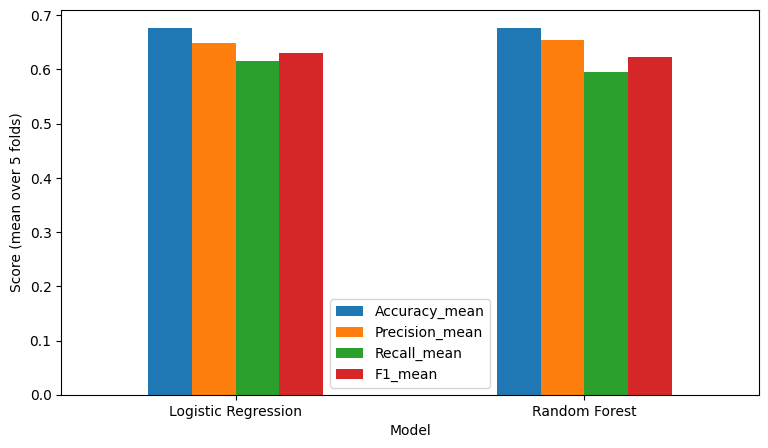

In [109]:
ax = comparison.set_index("Model")[["Accuracy_mean","Precision_mean","Recall_mean","F1_mean"]].plot.bar(rot=0, figsize=(9,5))
ax.set_ylabel("Score (mean over 5 folds)")


## ✅ Auswahl des finalen Modells

Die **logistische Regression** erzielte den **höchsten F1-Score**  
und zeigte **stabile Ergebnisse über alle Folds** hinweg.

---

### 🔍 Weitere Vorteile:
- Bessere **Interpretierbarkeit** der Einflussfaktoren  
  durch Analyse der **Modellkoeffizienten**

---

Aufgrund dieser Ergebnisse wurde die **logistische Regression**  
als **finales Modell ausgewählt** und anschließend auf dem **vollständigen Datensatz trainiert**.


In [110]:
pipeline_lr.fit(X_encoded, y)

print("Final model (Logistic Regression) trained on full dataset.")

Final model (Logistic Regression) trained on full dataset.


In [111]:
import joblib

joblib.dump(pipeline_lr, "../data/processed/final_model_logreg.joblib")

print("Final Logistic Regression model saved to data/processed/final_model_logreg.joblib")


Final Logistic Regression model saved to data/processed/final_model_logreg.joblib


In [112]:
model = pipeline_lr.named_steps["model"]

coef_series = (
    pd.Series(model.coef_[0], index=X_encoded.columns)
      .sort_values()
)

print("Stärkste negative Koeffizienten (senken Top-10-Wahrscheinlichkeit):")
print(coef_series.head(15))

print("\nStärkste positive Koeffizienten (erhöhen Top-10-Wahrscheinlichkeit):")
print(coef_series.tail(15))

Stärkste negative Koeffizienten (senken Top-10-Wahrscheinlichkeit):
season                  -0.759652
era_1990-2009           -0.552084
era_1970-1989           -0.515262
era_2010-2021           -0.311169
circuitId_64            -0.218419
grid_bucket_mid_11_20   -0.196575
era_2022+               -0.178516
circuitId_58            -0.167824
circuitId_19            -0.149719
circuitId_35            -0.141895
circuitId_60            -0.118757
driverId                -0.110023
circuitId_67            -0.109120
circuitId_68            -0.103815
circuitId_12            -0.096878
dtype: float64

Stärkste positive Koeffizienten (erhöhen Top-10-Wahrscheinlichkeit):
circuitId_62    0.069249
circuitId_76    0.078598
circuitId_6     0.084188
circuitId_53    0.092801
circuitId_45    0.102181
circuitId_75    0.122145
circuitId_52    0.126988
circuitId_61    0.131476
circuitId_65    0.141004
circuitId_54    0.166153
round           0.174341
circuitId_25    0.223168
circuitId_49    0.225895
circuitId_51

## 🏁 Ergebnis des Modelltrainings

Das **finale Modell** lernt eine **Abbildung von vor dem Rennen bekannten Merkmalen**  
auf die **Wahrscheinlichkeit einer Top-10-Platzierung**.

---

Durch den Einsatz von **Kreuzvalidierung** konnte gezeigt werden,  
dass das Modell auch auf **unbekannten Daten zuverlässig generalisiert**.

✅ Das Modell ist somit geeignet für **realistische Vorhersagen vor dem Rennstart**.
